# Project Summary: Property Data Analysis

In this notebook, we performed a complete data engineering and exploratory analysis workflow on a real estate dataset. Here is a summary of the actions taken:

### 1. Data Ingestion and Merging
*   **Source Data**: Loaded 14 individual CSV files representing different property types (Apartments, Villas, Chalets, etc.).
*   **Consolidation**: Merged all dataframes into a single master DataFrame (`df`) containing 8,597 records.

### 2. Data Cleaning & Transformation
*   **Feature Engineering**:
    *   Created a unique fixed-length `id` for every property.
    *   Developed an `embedding_text` column combining key features (location, property name, beds, baths, size) for future machine learning or search tasks.
*   **Price Cleaning**: Converted the `price` column from a string (e.g., '150,000,000 EGP') to a numeric `price_float` for calculation.
*   **Redundancy Removal**: Identified that `title` and `description` were identical and dropped the redundant `title` column.
*   **Schema Optimization**: Reordered columns to prioritize essential data while moving metadata (URLs, logos) to the end.

### 3. Exploratory Data Analysis (EDA)
*   **Outlier Detection**: Used the Interquartile Range (IQR) method to identify 413 high-price outliers.
*   **Comparative Analysis**: Found that price outliers are, on average, **1.93x larger** (in m2) than standard properties.
*   **Geographic Insights**: Identified **Ras El Hekma** and **New Cairo** as the most frequent locations in the dataset.
*   **Correlation Analysis**: Confirmed that property size (`m2`) is the strongest predictor of price (0.61 correlation), followed by the number of bathrooms.

### 4. Data Export
*   **Final Output**: Saved the fully cleaned and processed dataset as `nawy_properties_cleaned.csv` for downstream use.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

apartment_df = pd.read_csv("Apartment_nawy_properties.csv")
cabin_df = pd.read_csv("Cabin_nawy_properties.csv")
chalet_df = pd.read_csv("Chalet_nawy_properties.csv")
clinic_df = pd.read_csv("Clinic_nawy_properties.csv")
duplex_df = pd.read_csv("Duplex_nawy_properties.csv")
loft_df = pd.read_csv("Loft_nawy_properties.csv")
office_df = pd.read_csv("Office_nawy_properties.csv")
penthouse_df = pd.read_csv("Penthouse_nawy_properties.csv")
retail_df = pd.read_csv("Retail_nawy_properties.csv")
studio_df = pd.read_csv("Studio_nawy_properties.csv")
townhouse_df = pd.read_csv("Townhouse_nawy_properties.csv")
twinhouse_df = pd.read_csv("Twinhouse_nawy_properties.csv")
villa_df = pd.read_csv("Villa_nawy_properties.csv")
family_house_df = pd.read_csv("Family_House_Pharmacy_Building_Administrative_nawy_properties.csv")

In [ ]:
chalet_df.shape

(2867, 13)

In [ ]:
apartment_df.shape

(1286, 13)

In [ ]:
villa_df.head(1)

,url_path,tag,cover_image,location,property_name,developer_logo,title,description,m2,Beds,Baths,payment_plan,price
0,https://www.nawy.com/compound/79-marseilia-bea...,Resale,https://prod-images.cooingestate.com/processed...,North Coast-Sahel,"Villa, Marseilia Beach 4",https://prod-images.cooingestate.com/processed...,Villa for sale in Marseilia Beach 4 - with 8 b...,Villa for sale in Marseilia Beach 4 - with 8 b...,2000,8,8,NaN,"150,000,000 EGP"


In [ ]:
dataframes = [
    apartment_df,
    cabin_df,
    chalet_df,
    clinic_df,
    duplex_df,
    family_house_df,
    loft_df,
    office_df,
    penthouse_df,
    retail_df,
    studio_df,
    townhouse_df,
    twinhouse_df,
    villa_df
]

df = pd.concat(dataframes, ignore_index=True)
print(f"Combined DataFrame shape: {df.shape}")

Combined DataFrame shape: (8597, 13)


In [ ]:
df.head(2)

,url_path,tag,cover_image,location,property_name,developer_logo,title,description,m2,Beds,Baths,payment_plan,price
0,https://www.nawy.com/compound/623-celia/proper...,Resale,https://prod-images.cooingestate.com/processed...,New Capital City,"Apartment, Celia",https://prod-images.cooingestate.com/processed...,Apartment for sale in Celia - with 2 bedrooms ...,Apartment for sale in Celia - with 2 bedrooms ...,101.0,2.0,1.0,"32,083 EGP monthly / 2 Years","4,200,000 EGP"
1,https://www.nawy.com/compound/1364-noi/propert...,NaN,https://prod-images.cooingestate.com/processed...,6th settlement,"Apartment, Noi",https://prod-images.cooingestate.com/processed...,Apartment for sale in Noi - with 1 bedroom in ...,Apartment for sale in Noi - with 1 bedroom in ...,81.0,1.0,1.0,"274,567 EGP quarterly / 8 Years","8,786,151 EGP"


In [ ]:
cols_to_move = ['url_path', 'tag', 'cover_image', 'developer_logo']

# Get all columns except the ones to move
other_cols = [col for col in df.columns if col not in cols_to_move]

# Create the new column order: other_cols followed by cols_to_move
new_col_order = other_cols + cols_to_move

# Reindex the DataFrame with the new column order
df = df[new_col_order]

print("Columns reordered successfully. Displaying the first 2 rows with the new column order:")
df.head(2)

Columns reordered successfully. Displaying the first 2 rows with the new column order:


,location,property_name,title,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo
0,New Capital City,"Apartment, Celia",Apartment for sale in Celia - with 2 bedrooms ...,Apartment for sale in Celia - with 2 bedrooms ...,101.0,2.0,1.0,"32,083 EGP monthly / 2 Years","4,200,000 EGP",https://www.nawy.com/compound/623-celia/proper...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...
1,6th settlement,"Apartment, Noi",Apartment for sale in Noi - with 1 bedroom in ...,Apartment for sale in Noi - with 1 bedroom in ...,81.0,1.0,1.0,"274,567 EGP quarterly / 8 Years","8,786,151 EGP",https://www.nawy.com/compound/1364-noi/propert...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8597 entries, 0 to 8596
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        8597 non-null   object 
 1   property_name   8597 non-null   object 
 2   title           8597 non-null   object 
 3   description     8597 non-null   object 
 4   m2              8585 non-null   float64
 5   Beds            7765 non-null   float64
 6   Baths           7843 non-null   float64
 7   payment_plan    6438 non-null   object 
 8   price           8597 non-null   object 
 9   url_path        8597 non-null   object 
 10  tag             5539 non-null   object 
 11  cover_image     8597 non-null   object 
 12  developer_logo  8587 non-null   object 
dtypes: float64(3), object(10)
memory usage: 873.3+ KB


In [ ]:
# Clean the price strings and convert to numeric, turning non-numeric strings into NaN
clean_price = df['price'].str.replace(' EGP', '').str.replace(',', '')
df['price_float'] = pd.to_numeric(clean_price, errors='coerce')

print("Price_float column created. Summary (NaNs represent 'Prices To Be Announced'):")
print(df['price_float'].describe())

Price_float column created. Summary (NaNs represent 'Prices To Be Announced'):
count    8.578000e+03
mean     1.617372e+07
std      1.422079e+07
min      1.300000e+06
25%      8.800000e+06
50%      1.350000e+07
75%      1.958806e+07
max      4.150000e+08
Name: price_float, dtype: float64


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
location,0
property_name,0
title,0
description,0
m2,12
Beds,832
Baths,754
payment_plan,2159
price,0
url_path,0


In [ ]:
# Check if 'title' and 'description' are identical for each row
same_content = (df['title'] == df['description']).all()
count_same = (df['title'] == df['description']).sum()

print(f"Are all titles identical to descriptions? {same_content}")
print(f"Number of rows where title matches description: {count_same} out of {len(df)}")

Are all titles identical to descriptions? True
Number of rows where title matches description: 8597 out of 8597


In [ ]:
# Drop the 'title' column as it is identical to 'description'
df.drop(columns=['title'], inplace=True)

print("Column 'title' dropped. Updated columns:")
print(df.columns.tolist())

Column 'title' dropped. Updated columns:
['location', 'property_name', 'description', 'm2', 'Beds', 'Baths', 'payment_plan', 'price', 'url_path', 'tag', 'cover_image', 'developer_logo', 'price_float']


In [ ]:
df.head(2)

,location,property_name,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo,price_float
0,New Capital City,"Apartment, Celia",Apartment for sale in Celia - with 2 bedrooms ...,101.0,2.0,1.0,"32,083 EGP monthly / 2 Years","4,200,000 EGP",https://www.nawy.com/compound/623-celia/proper...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,4200000.0
1,6th settlement,"Apartment, Noi",Apartment for sale in Noi - with 1 bedroom in ...,81.0,1.0,1.0,"274,567 EGP quarterly / 8 Years","8,786,151 EGP",https://www.nawy.com/compound/1364-noi/propert...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,8786151.0


In [ ]:
# Display a random sample of 5 rows from the combined DataFrame
df.sample(5)

,location,property_name,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo,price_float
6741,6th of October City,"Retail, Jazebeya",Retail for sale in Jazebeya - with in 6th of O...,58.0,NaN,NaN,"360,905 EGP quarterly / 8 Years","12,156,800 EGP",https://www.nawy.com/compound/1130-jazebeya/pr...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,12156800.0
2854,Ras El Hekma,"Chalet, Fouka Bay",Chalet for sale in Fouka Bay - with 3 bedrooms...,125.0,3.0,2.0,"293,826 EGP monthly / 6 Years","23,655,487 EGP",https://www.nawy.com/compound/84-fouka-bay/pro...,Nawy Now,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,23655487.0
5298,Al Alamein,"Duplex, Mazarine",Duplex for sale in Mazarine - with 2 bedrooms ...,316.0,2.0,2.0,"1,154,175 EGP quarterly / 3 Years","15,389,000 EGP",https://www.nawy.com/compound/293-mazarine/pro...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,15389000.0
3323,Al Dabaa,"Chalet, Southmed",Chalet for sale in Southmed - with 2 bedrooms ...,133.0,2.0,3.0,"45,865 EGP monthly / 12 Years","15,835,910 EGP",https://www.nawy.com/compound/1198-southmed/pr...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,15835910.0
6273,New Cairo,"Office, The Gray",An office in The Gray by Housing and Developm...,62.0,NaN,NaN,"837,000 EGP quarterly / 4 Years","14,880,000 EGP",https://www.nawy.com/compound/1214-the-gray/pr...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,14880000.0


In [ ]:
# Create a unique identifier column for each row
# Using zfill to create a fixed length string ID (e.g., 5 digits: 00001)
num_digits = 5
df['id'] = range(len(df))
df['id'] = df['id'].astype(str).str.zfill(num_digits)

# Move the 'id' column to the front for better visibility
cols = ['id'] + [col for col in df.columns if col != 'id']
df = df[cols]

print(f"Fixed-length ID column (length {num_digits}) created. Displaying 5 random rows:")
df.sample(5)

Fixed-length ID column (length 5) created. Displaying 5 random rows:


,id,location,property_name,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo,price_float
4174,04174,Ras El Hekma,"Chalet, Hacienda Waters",Chalet for sale in Hacienda Waters - with 2 b...,114.0,2.0,3.0,"118,170 EGP monthly / 9 Years","14,966,000 EGP",https://www.nawy.com/compound/1261-hacienda-wa...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,14966000.0
809,00809,Mostakbal City,"Apartment, Nyoum Mostaqbal City",Apartment for sale in Nyoum Mostaqbal City - w...,103.0,2.0,2.0,"16,960 EGP monthly / 6 Years","4,001,445 EGP",https://www.nawy.com/compound/892-nyoum-mostaq...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,4001445.0
6663,06663,El Sheikh Zayed,"Retail, D Line",Retail for sale in D Line - with in El Sheikh ...,142.0,NaN,NaN,"1,691,500 EGP quarterly / 5 Years","39,800,000 EGP",https://www.nawy.com/compound/980-d-line/prope...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,39800000.0
5050,05050,New Capital City,"Duplex, Jade Park",Duplex for sale in Jade Park - with 4 bedrooms...,692.0,4.0,3.0,"840,292 EGP quarterly / 12 Years","43,000,000 EGP",https://www.nawy.com/compound/1463-jade-park/p...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,43000000.0
6335,06335,6th of October City,"Penthouse, PX",Penthouse for sale in PX - with 2 bedrooms in ...,114.0,2.0,3.0,"158,310 EGP monthly / 7 Years","17,429,000 EGP",https://www.nawy.com/compound/1154-px/property...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,17429000.0


In [ ]:
# Define columns to include in the embedding text
embed_cols = ['id', 'location', 'property_name', 'description', 'Beds', 'Baths', 'm2', 'tag']

# Create a function to combine the columns into a single string, handling NaNs
def combine_features(row):
    features = []
    for col in embed_cols:
        val = row[col]
        if pd.notna(val):
            features.append(f"{col}: {val}")
    return " | ".join(features)

# Apply the function to create the embedding_text column
df['embedding_text'] = df.apply(combine_features, axis=1)

print("Column 'embedding_text' created. Displaying a sample of the first row's content:")
print(df['embedding_text'].iloc[0])
display(df[['id', 'embedding_text']].head())

Column 'embedding_text' created. Displaying a sample of the first row's content:
id: 00000 | location: New Capital City | property_name: Apartment, Celia | description: Apartment for sale in Celia - with 2 bedrooms in New Capital City by Talaat Moustafa Group (TMG) Holding. | Beds: 2.0 | Baths: 1.0 | m2: 101.0 | tag: Resale


,id,embedding_text
0,00000,id: 00000 | location: New Capital City | prope...
1,00001,id: 00001 | location: 6th settlement | propert...
2,00002,id: 00002 | location: 6th settlement | propert...
3,00003,id: 00003 | location: El Sheikh Zayed | proper...
4,00004,id: 00004 | location: 6th of October City | pr...


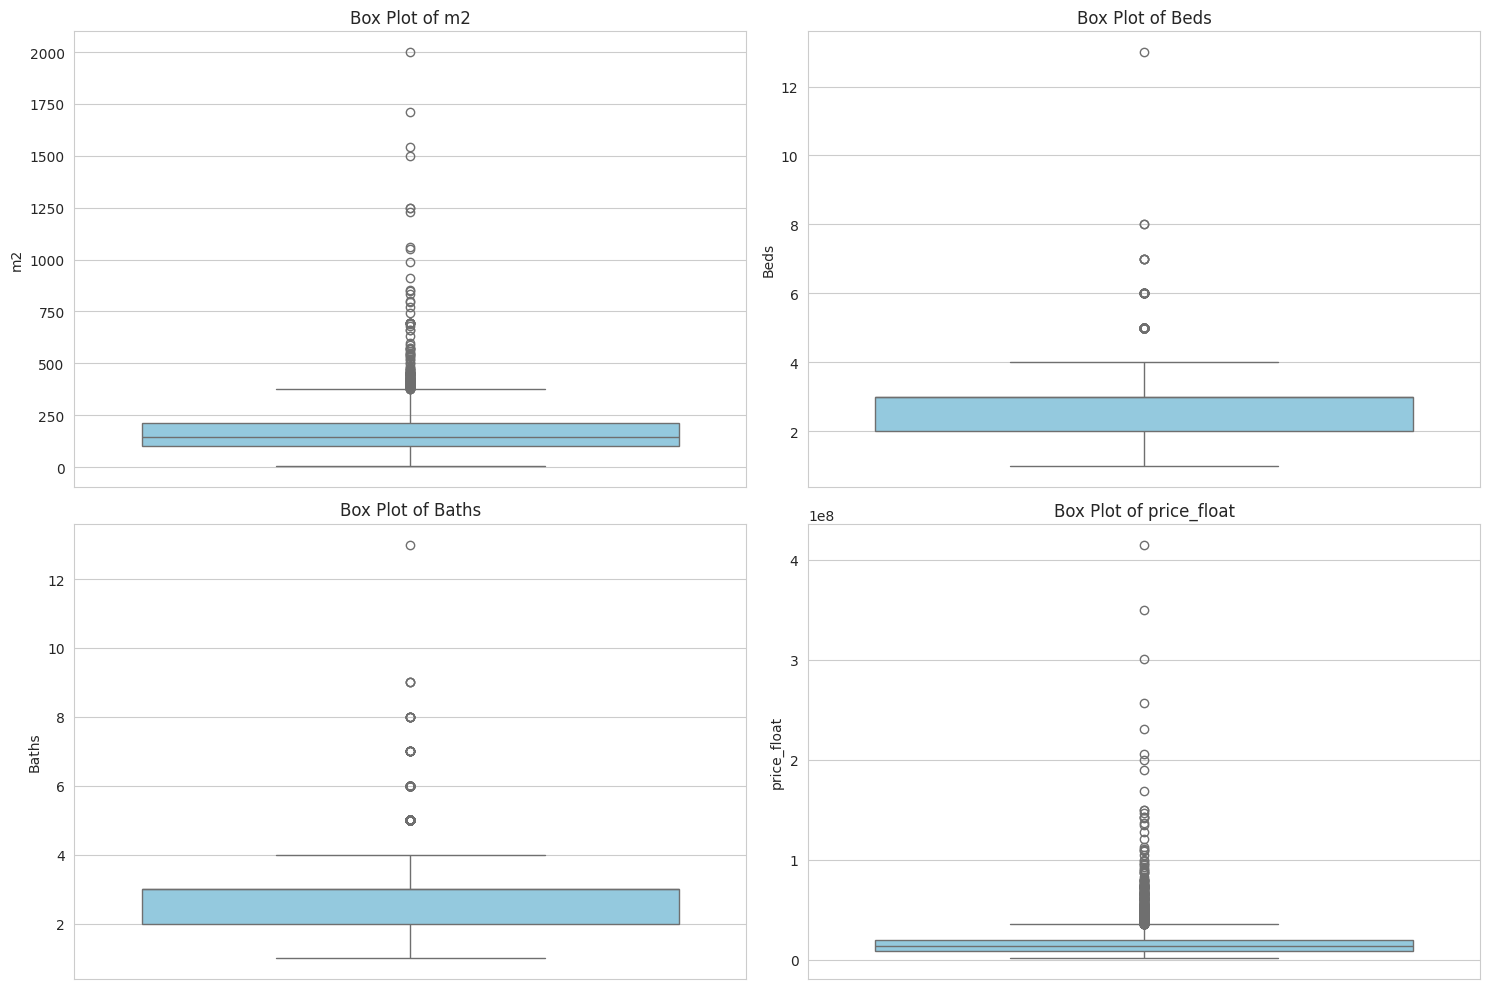

In [ ]:
# Identify float columns for box plots
float_cols = ['m2', 'Beds', 'Baths', 'price_float']

# Set a style for the plots
sns.set_style("whitegrid")

# Create box plots for each float column
plt.figure(figsize=(15, 10))
for i, col in enumerate(float_cols):
    plt.subplot(2, 2, i + 1)  # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
Q1 = df['price_float'].quantile(0.25)
Q3 = df['price_float'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outlier rows
outliers_price = df[(df['price_float'] < lower_bound) | (df['price_float'] > upper_bound)]

print(f"Number of outliers in 'price_float': {len(outliers_price)}")
print("Displaying the first 5 rows of identified price outliers:")
display(outliers_price.head())

Number of outliers in 'price_float': 413
Displaying the first 5 rows of identified price outliers:


,id,location,property_name,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo,price_float,embedding_text
99,00099,Sidi Heneish,"Apartment, Silvertown Silversands",Apartment for sale in Silvertown Silversands -...,211.0,4.0,3.0,"1,008,759 EGP quarterly / 10 Years","47,471,000 EGP",https://www.nawy.com/compound/717-silvertown-s...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,47471000.0,id: 00099 | location: Sidi Heneish | property_...
173,00173,El Choueifat,"Apartment, WBR1",Apartment for sale in WBR1 - with 2 bedrooms...,175.0,2.0,2.0,"1,925,000 EGP quarterly / 5 Years","48,125,000 EGP",https://www.nawy.com/compound/359-wbr1/propert...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,48125000.0,id: 00173 | location: El Choueifat | property_...
194,00194,Sidi Heneish,"Apartment, Branded Residences - Silversands",Apartment for sale in Branded Residences - Sil...,122.0,2.0,3.0,"1,340,521 EGP quarterly / 6 Years","37,850,000 EGP",https://www.nawy.com/compound/1475-branded-res...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,37850000.0,id: 00194 | location: Sidi Heneish | property_...
247,00247,El Sheikh Zayed,"Apartment, 205 Towers",Apartment for sale in 205 Towers - with 3 bedr...,387.0,3.0,4.0,"2,224,586 EGP quarterly / 8 Years","79,096,400 EGP",https://www.nawy.com/compound/1535-205-towers/...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,79096400.0,id: 00247 | location: El Sheikh Zayed | proper...
301,00301,El Sheikh Zayed,"Apartment, Casa D'Or - Zed",Apartment for sale in Casa D'Or - Zed - with ...,169.0,2.0,3.0,"339,347 EGP monthly / 7 Years","42,003,295 EGP",https://www.nawy.com/compound/1038-casa-d'or-z...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,42003295.0,id: 00301 | location: El Sheikh Zayed | proper...


Location distribution for outlier properties:
location
New Cairo              72
Ras El Hekma           45
Sidi Abdel Rahman      42
El Sheikh Zayed        39
6th of October City    28
Al Dabaa               22
North Coast-Sahel      19
New Capital City       18
New Zayed              17
Sidi Heneish           15
Name: count, dtype: int64


/tmp/ipykernel_8190/1533852270.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outlier_location_distribution.head(10).index, y=outlier_location_distribution.head(10).values, palette='viridis')


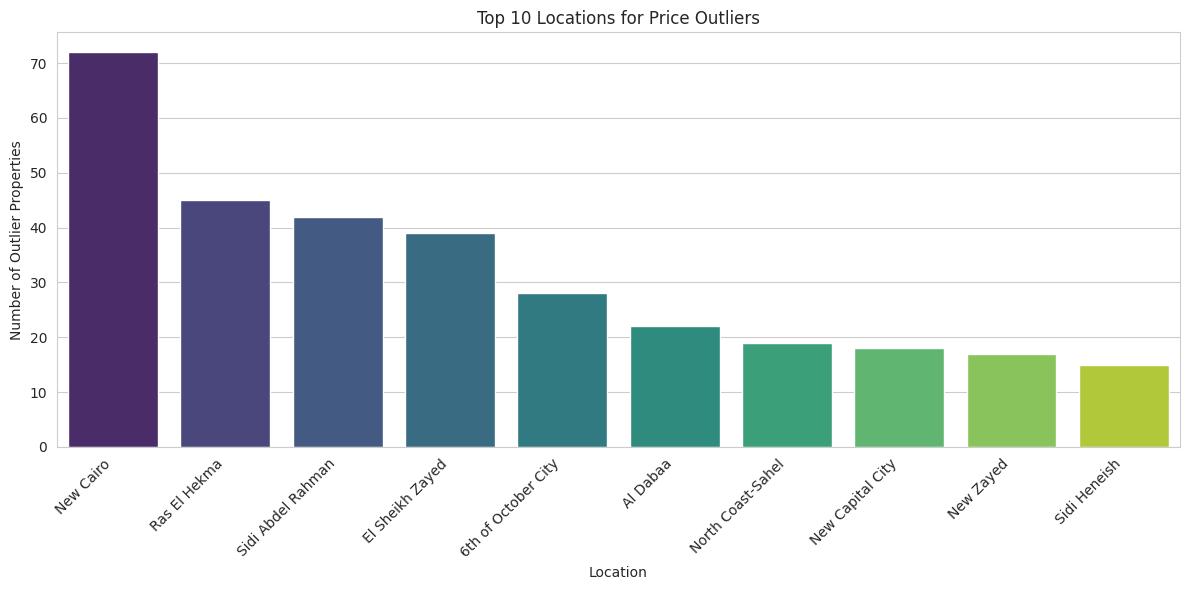

In [ ]:
# Get the location distribution for outlier properties
outlier_location_distribution = outliers_price['location'].value_counts()

print("Location distribution for outlier properties:")
print(outlier_location_distribution.head(10)) # Display top 10 locations

# Visualize the top locations for outliers
plt.figure(figsize=(12, 6))
sns.barplot(x=outlier_location_distribution.head(10).index, y=outlier_location_distribution.head(10).values, palette='viridis')
plt.title('Top 10 Locations for Price Outliers')
plt.xlabel('Location')
plt.ylabel('Number of Outlier Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Create a DataFrame for non-outlier rows
non_outliers_df = df[~df.index.isin(outliers_price.index)]

# Calculate average m2 for outliers and non-outliers
avg_m2_outliers = outliers_price['m2'].mean()
avg_m2_non_outliers = non_outliers_df['m2'].mean()

print(f"Average m2 for price outliers: {avg_m2_outliers:.2f}")
print(f"Average m2 for non-outliers: {avg_m2_non_outliers:.2f}")

# Calculate the ratio
if avg_m2_non_outliers > 0:
    ratio = avg_m2_outliers / avg_m2_non_outliers
    print(f"\nPrice outliers are, on average, {ratio:.2f}x larger than standard properties.")

Average m2 for price outliers: 298.01
Average m2 for non-outliers: 154.09

Price outliers are, on average, 1.93x larger than standard properties.



Overall location distribution (top 10):
location
Ras El Hekma           1606
New Cairo              1354
New Capital City        657
Ain Sokhna              597
6th of October City     559
Mostakbal City          545
Sidi Abdel Rahman       476
El Sheikh Zayed         330
Sidi Heneish            269
New Zayed               267
Name: count, dtype: int64


/tmp/ipykernel_8190/1695643393.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_location_distribution.head(10).index, y=overall_location_distribution.head(10).values, palette='plasma')


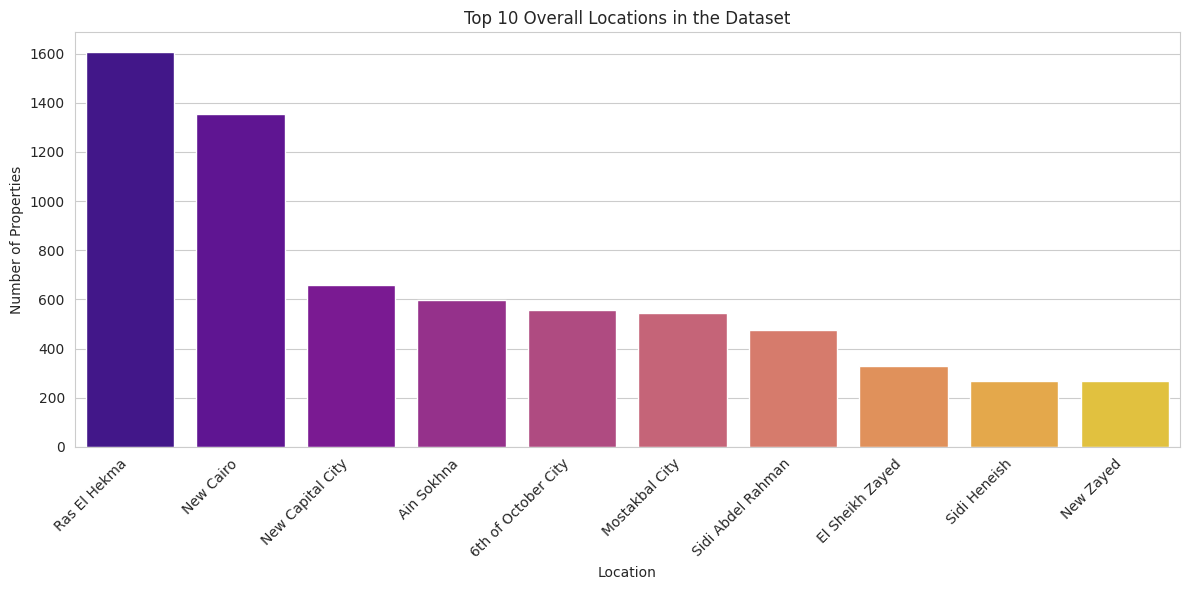

In [ ]:
# For comparison, let's also look at the overall location distribution
overall_location_distribution = df['location'].value_counts()

print("\nOverall location distribution (top 10):")
print(overall_location_distribution.head(10))

# Visualize the top overall locations
plt.figure(figsize=(12, 6))
sns.barplot(x=overall_location_distribution.head(10).index, y=overall_location_distribution.head(10).values, palette='plasma')
plt.title('Top 10 Overall Locations in the Dataset')
plt.xlabel('Location')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_8190/1556351054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=location_counts.index, y=location_counts.values, palette='viridis')


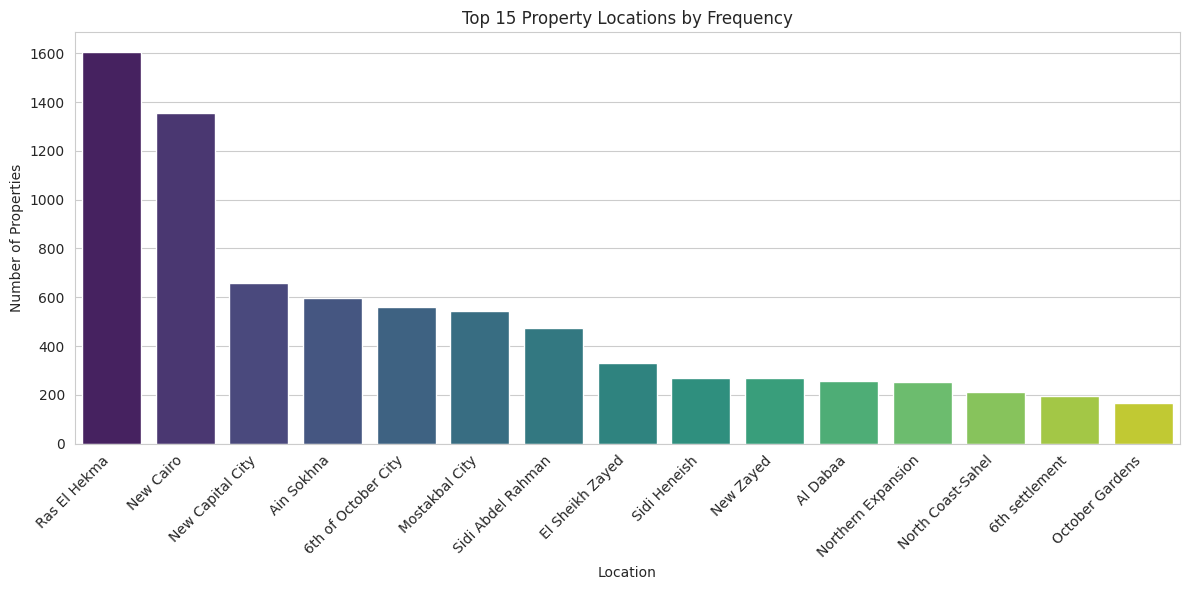

In [ ]:
# Calculate location value counts
location_counts = df['location'].value_counts().head(15)

# Create the bar graph
plt.figure(figsize=(12, 6))
sns.barplot(x=location_counts.index, y=location_counts.values, palette='viridis')
plt.title('Top 15 Property Locations by Frequency')
plt.xlabel('Location')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.location.value_counts()

,count
location,
Ras El Hekma,1606
New Cairo,1354
New Capital City,657
Ain Sokhna,597
6th of October City,559
Mostakbal City,545
Sidi Abdel Rahman,476
El Sheikh Zayed,330
Sidi Heneish,269


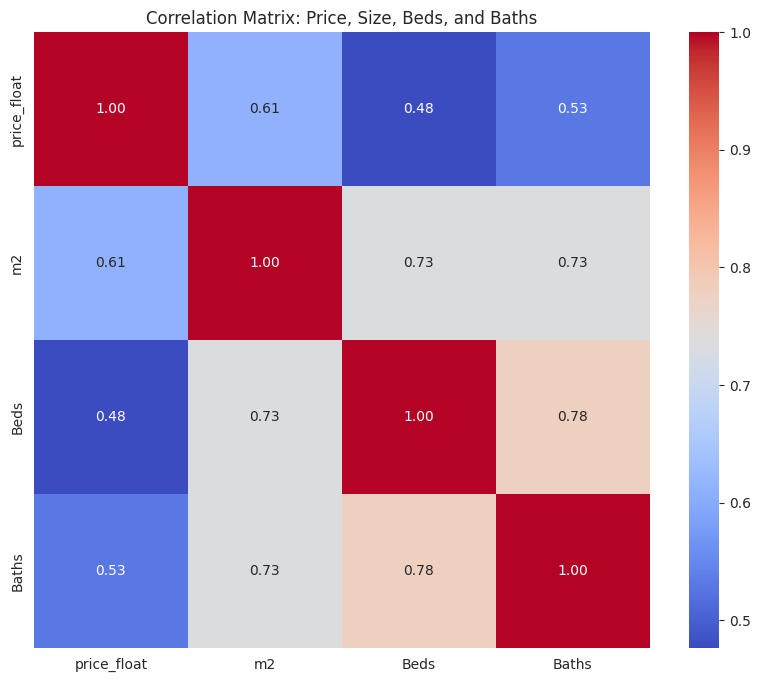

In [ ]:
# Identify all float columns for correlation
float_cols = ['price_float', 'm2', 'Beds', 'Baths']

# Calculate correlation matrix for all float columns
correlation_matrix = df[float_cols].corr()

# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix: Price, Size, Beds, and Baths')
plt.show()

**Observations:**

- m2 remains the strongest predictor of **price_float** (0.61).
- **Beds** and **Baths** are very highly correlated with each other (0.78) and with property size (**m2**), which is expected.
- **Baths** actually shows a slightly higher correlation with **price_float** (0.53) than **Beds** (0.48), possibly suggesting that luxury properties with more bathrooms command higher premiums.

In [ ]:
df.sample(5)

,id,location,property_name,description,m2,Beds,Baths,payment_plan,price,url_path,tag,cover_image,developer_logo,price_float,embedding_text
7692,07692,Sahl Hasheesh,"Townhouse, Amber-Il Bayou",Townhouse for sale in Amber-Il Bayou - with 4 ...,176.0,4.0,4.0,"894,087 EGP quarterly / 6 Years","25,244,800 EGP",https://www.nawy.com/compound/1667-amber-il-ba...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,25244800.0,id: 07692 | location: Sahl Hasheesh | property...
4402,04402,New Capital City,"Clinic, City Hall Strip",Clinic for sale in City Hall Strip - with in N...,52.0,NaN,NaN,"260,000 EGP quarterly / 6 Years","6,933,333 EGP",https://www.nawy.com/compound/1083-city-hall-s...,NaN,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,6933333.0,id: 04402 | location: New Capital City | prope...
3957,03957,Ras El Hekma,"Chalet, Hyde Park North - Seashore",Chalet for sale in Hyde Park North - Seashore ...,100.0,2.0,2.0,"121,730 EGP monthly / 8 Years","13,869,430 EGP",https://www.nawy.com/compound/522-hyde-park-no...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,13869430.0,id: 03957 | location: Ras El Hekma | property_...
2427,02427,Ras El Hekma,"Chalet, El Masyaf",Chalet for sale in El Masyaf - with 2 bedroom...,100.0,2.0,2.0,"130,760 EGP monthly / 8 Years","16,092,500 EGP",https://www.nawy.com/compound/232-el-masyaf/pr...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,16092500.0,id: 02427 | location: Ras El Hekma | property_...
4639,04639,New Cairo,"Duplex, Mountain View Executive Residence Kat...",Duplex for sale in Mountain View Executive Res...,287.0,3.0,3.0,NaN,"16,600,000 EGP",https://www.nawy.com/compound/451-mountain-vie...,Resale,https://prod-images.cooingestate.com/processed...,https://prod-images.cooingestate.com/processed...,16600000.0,id: 04639 | location: New Cairo | property_nam...


In [ ]:
df.shape

(8597, 15)

In [ ]:
df.to_csv('nawy_properties_cleaned.csv', index=False)
print("DataFrame saved successfully as 'nawy_properties_cleaned.csv'")

DataFrame saved successfully as 'nawy_properties_cleaned.csv'
